# Credit Card Fraud Detection

### Author: Sanjith

### Objective

Build a machine learning model to detect fraudulent credit card transactions using SMOTE, Random Forest, XGBoost, and LightGBM.

# 1. Import Libraries

In [33]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

import joblib

# 2. load dataset

In [34]:
df = pd.read_csv("../data/creditcard.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# 3.Exploratory Data Analysis 

(284807, 31)


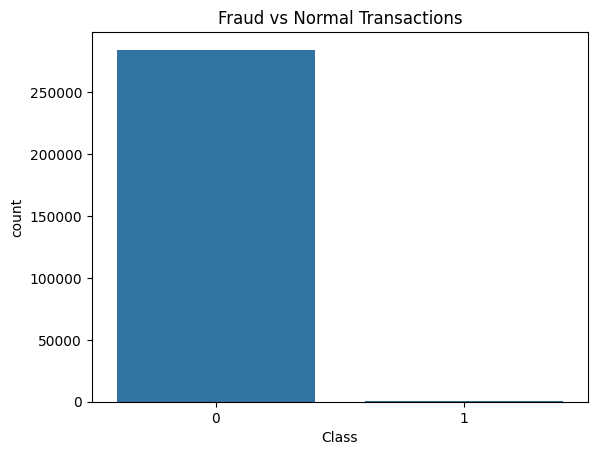

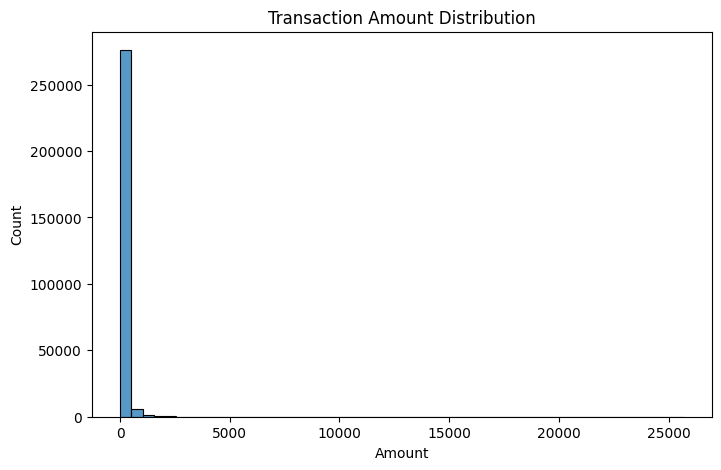

In [35]:
print(df.shape)
df.isnull().sum()
df["Class"].value_counts()
df["Class"].value_counts(normalize=True) * 100
sns.countplot(x="Class", data=df)

plt.title("Fraud vs Normal Transactions")

plt.show()
plt.figure(figsize=(8,5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

# 4. Data Preprocessing

In [36]:
X = df.drop("Class", axis=1)

y = df["Class"]
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 5. Handle Class Imbalance using SMOTE

Class
0    227451
1       394
Name: count, dtype: int64
Class
0    227451
1    227451
Name: count, dtype: int64


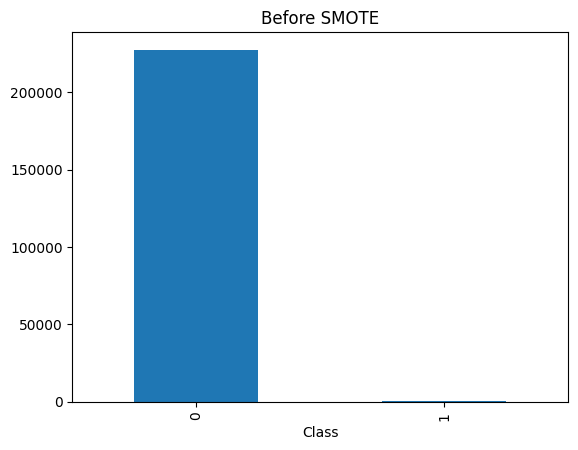

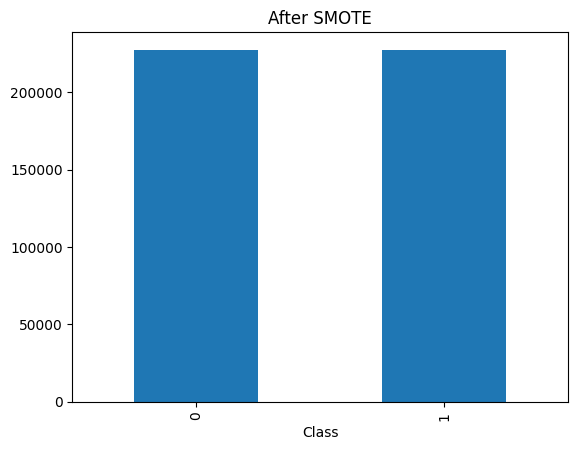

In [37]:
print(y_train.value_counts())
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)
print(y_train_smote.value_counts())
y_train.value_counts().plot(kind="bar")

plt.title("Before SMOTE")

plt.show()
y_train_smote.value_counts().plot(kind="bar")

plt.title("After SMOTE")

plt.show()

# 6. Train Models

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,      # Use all CPU cores
    verbose=1       # Show progress
)

rf_model.fit(X_train_smote, y_train_smote)

rf_preds = rf_model.predict(X_valid)

rf_probs = rf_model.predict_proba(X_valid)[:, 1]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   28.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.2min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


In [39]:
xgb_model = XGBClassifier(
    random_staite=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

xgb_preds = xgb_model.predict(X_valid)

xgb_probs = xgb_model.predict_proba(X_valid)[:,1]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [19:25:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "random_staite" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [40]:
lgb_model = LGBMClassifier(random_state=42)

lgb_model.fit(
    X_train_smote,
    y_train_smote
)

lgb_preds = lgb_model.predict(X_valid)

lgb_probs = lgb_model.predict_proba(X_valid)[:,1]

[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004047 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


# 7. Compare Models

In [41]:
results = pd.DataFrame({
    "Model":[
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "Accuracy":[
        accuracy_score(y_valid, rf_preds),
        accuracy_score(y_valid, xgb_preds),
        accuracy_score(y_valid, lgb_preds)
    ],
    "ROC-AUC":[
        roc_auc_score(y_valid, rf_probs),
        roc_auc_score(y_valid, xgb_probs),
        roc_auc_score(y_valid, lgb_probs)
    ]
})

results

,Model,Accuracy,ROC-AUC
0,Random Forest,0.999403,0.964421
1,XGBoost,0.999350,0.983115
2,LightGBM,0.998736,0.913421


# 8. Threshold Tuning

In [42]:
thresholds = [0.30,0.50,0.70]
for t in thresholds:

    preds = (lgb_probs >= t).astype(int)

    print("Threshold:",t)

    print("Precision:",
          precision_score(y_valid,preds))

    print("Recall:",
          recall_score(y_valid,preds))

    print("----------------")

Threshold: 0.3
Precision: 0.45714285714285713
Recall: 0.8163265306122449
----------------
Threshold: 0.5
Precision: 0.5984848484848485
Recall: 0.8061224489795918
----------------
Threshold: 0.7
Precision: 0.7181818181818181
Recall: 0.8061224489795918
----------------


# 9. Final Model Evaluation

In [43]:
accuracy = accuracy_score(
    y_valid,
    xgb_preds
)

print("Accuracy:", accuracy)

Accuracy: 0.9993504441557529


In [44]:
precision = precision_score(
    y_valid,
    xgb_preds
)

print("Precision:", precision)

Precision: 0.7904761904761904


In [45]:
recall = recall_score(
    y_valid,
    xgb_preds
)

print("Recall:", recall)

Recall: 0.8469387755102041


In [46]:
f1 = f1_score(
    y_valid,
    xgb_preds
)

print("F1 Score:", f1)

F1 Score: 0.8177339901477833


In [47]:
roc_auc = roc_auc_score(
    y_valid,
    xgb_probs
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9831145633548861


In [48]:
cm = confusion_matrix(
    y_valid,
    xgb_preds
)

print(cm)

[[56842    22]
 [   15    83]]


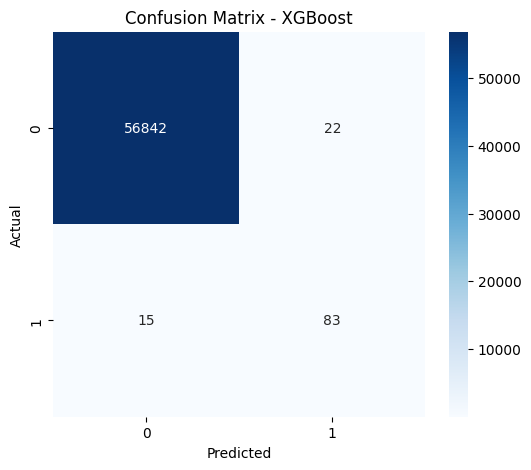

In [49]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [50]:
print(
    classification_report(
        y_valid,
        xgb_preds
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.85      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962



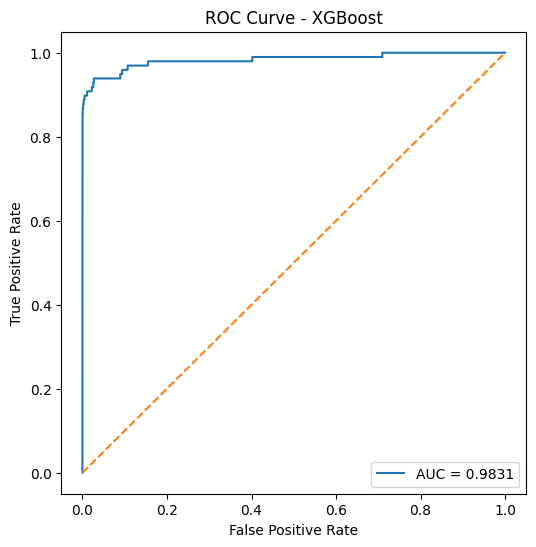

In [51]:
fpr, tpr, thresholds = roc_curve(
    y_valid,
    xgb_probs
)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1], [0,1], "--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend()

plt.show()

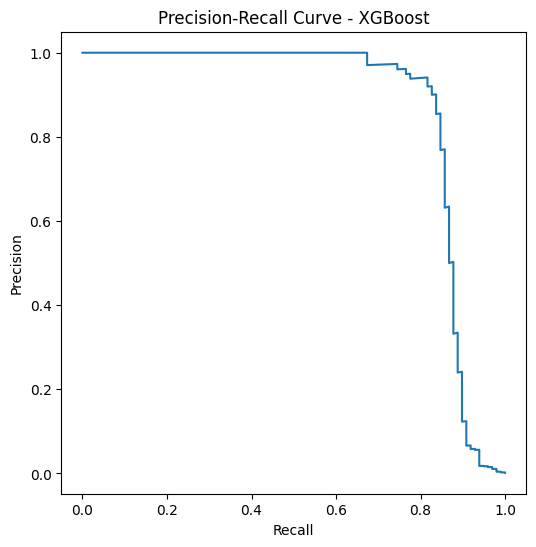

In [52]:
precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_valid,
    xgb_probs
)

plt.figure(figsize=(6,6))

plt.plot(recall_curve, precision_curve)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve - XGBoost")

plt.show()

In [53]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results

,Metric,Value
0,Accuracy,0.999350
1,Precision,0.790476
2,Recall,0.846939
3,F1 Score,0.817734
4,ROC-AUC,0.983115


# 10. Save Model


In [54]:
import joblib

joblib.dump(
    lgb_model,
    "../models/lightgbm_model.pkl"
)

['../models/lightgbm_model.pkl']

# Conclusion

This project focused on detecting fraudulent credit card transactions using machine learning.

The dataset was highly imbalanced, so SMOTE was applied to balance the minority class before training.

Three models were trained and evaluated:

- Random Forest
- XGBoost
- LightGBM

The models were compared using Accuracy and ROC-AUC.

Although Random Forest achieved the highest Accuracy (99.94%), XGBoost achieved the highest ROC-AUC score (98.31%), indicating better overall discrimination between fraudulent and legitimate transactions.

Therefore, XGBoost was selected as the final model for this project.

The trained XGBoost model was saved using Joblib for future deployment.
